# START


In [1]:
import os
import cv2
import importlib
import numpy as np
from tqdm.notebook import tqdm
from datetime import datetime
# ------------------------- new helpers ------------------------
import utils_setup as setup

In [2]:
import utils_setup as setup

if __name__ == "__main__":
    video_path = r"D:\DS\SR\v2\camera1_20251210_142154_normal.mp4"  # ← change this
    meta = setup.get_video_metadata(video_path, read_probe_frame=True)
    setup.print_video_metadata(meta, print_full=False)


Path               : D:\DS\SR\v2\camera1_20251210_142154_normal.mp4
Resolution         : 2560x1440
FPS                : 24.98999384236453
Frames             : 32467
Duration (s)       : 1299.2
Codec (FOURCC)     : hevc
File Size (MB)     : 486.955
Est. Bitrate (bps) : 3144144


## GENERATE_MASKED_VIDEO

In [3]:
GENERATE_MASKED_VIDEO = False
# GENERATE_MASKED_VIDEO = True

In [4]:
# ------------------------- usage example -------------------------
importlib.reload(setup)
if __name__ == "__main__":
    video_path = r"D:\DS\SR\v2\camera1_20251210_142154_normal.mp4"
    out_path  = r"D:\DS\SR\v2/\camera1_20251210_142154_annotated.mp4"
    dataset_source='SR' # SR, ValeriaLab
    dataset_version='v2'
    start_frame = 0
    end_frame = None  # set to None to process till end
    
    # Three per-frame mask templates (use {i} for frame index; adjust folder/zero-padding to your files)
    safety_area_ls = ['PLeft','PRight', 'ConvBelt', 'RoboArm']
    mask_temps = []
    for safety_area in safety_area_ls:
        mask_p=f"D:/DS/SR/{dataset_version}/masks/Mask Generation_{safety_area}_MASK.png"
        mask_temps.append(mask_p)
    time_start = datetime.now()
    print('='*100)
    print(f"\n--- Processing started at {time_start.strftime('%Y-%m-%d %H:%M:%S')}) ---")
    if GENERATE_MASKED_VIDEO:
        setup.overlay_masks_and_save_video(
            video_path=video_path,
            out_video_path=out_path,
            mask_templates=mask_temps,
            # colors=[(0,255,0), (0,0,255), (255,0,0)],  # BGR
            # colors=[(255,255,255), (255,255,255), (255,255,255), (255,255,255)],  # BGR
            colors=[(255,255,255),(255,255,255), (255,255,255), (255,255,255)],  # BGR
            font_size=1.5,
            thickness=4,
            # alpha_fill=0.15,  # nice translucent fill
            start_frame=start_frame,
            end_frame=end_frame,
            step=1,
            fourcc_str="mp4v",  # change to "XVID" for .avi if needed
            fps_override=None,
            alpha_fill=0.15,
            dim_alpha=0.65,
        )
    print('-'*100)
    print(f"--- Completed processing for at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} ---")
    print(f'Time taken: {format(datetime.now() - time_start)}')
# ------------------------- end -------------------------


--- Processing started at 2026-07-24 10:41:12) ---
----------------------------------------------------------------------------------------------------
--- Completed processing for at 2026-07-24 10:41:12 ---
Time taken: 0:00:00


In [5]:
import math
from typing import Tuple

def parse_timestamp(ts: str) -> float:
    """
    Parse 'SS', 'MM:SS', 'HH:MM:SS', with optional .ms on the last field.
    Returns total seconds as float.
    Examples: '37', '1:30', '02:10.250', '7:43.56', '00:07:43.560'
    """
    parts = ts.strip().split(":")
    parts = [p.strip() for p in parts if p.strip() != ""]
    if not parts:
        raise ValueError("Empty timestamp")

    # seconds (last) may contain decimals
    sec = float(parts[-1])
    mins = int(parts[-2]) if len(parts) >= 2 else 0
    hrs = int(parts[-3]) if len(parts) == 3 else 0
    if len(parts) > 3:
        raise ValueError(f"Too many ':' groups in timestamp: {ts}")

    return hrs * 3600 + mins * 60 + sec


def time_to_frame(ts: str, fps: float, clamp_max: int) -> int:
    """
    Convert a timestamp to a 0-based frame index.
    Rounds to nearest frame (good for seeking to a single point).
    Optionally clamps to [0, clamp_max-1].
    """
    t = parse_timestamp(ts)
    f = int(round(t * fps))
    if clamp_max is not None:
        f = max(0, min(f, clamp_max - 1))
    return f


def frame_to_time(frame_idx: int, fps: float) -> str:
    """
    Convert a 0-based frame index to 'MM:SS.sss' (or 'HH:MM:SS.sss' if needed).
    """
    t = frame_idx / fps
    hrs = int(t // 3600); t -= hrs * 3600
    mins = int(t // 60);  t -= mins * 60
    secs = t
    if hrs > 0:
        return f"{hrs:02d}:{mins:02d}:{secs:06.3f}"
    else:
        return f"{mins:02d}:{secs:06.3f}"  # MM:SS.sss


def range_to_frames(start_ts: str, end_ts: str, fps: float, frame_count: int) -> Tuple[int, int]:
    """
    Convert a [start, end) time window (end is exclusive in time) to an
    inclusive frame-index range [start_frame, end_frame].

    start_frame = floor(start_sec * fps)
    end_frame   = min(N-1, ceil(end_sec * fps) - 1)

    This mapping is ideal for extracting all frames that intersect the time window.
    """
    start_s = parse_timestamp(start_ts)
    end_s   = parse_timestamp(end_ts)
    if end_s < start_s:
        raise ValueError("end_ts must be >= start_ts")

    start_frame = int(math.floor(start_s * fps + 1e-9))
    end_frame   = min(frame_count - 1, int(math.ceil(end_s * fps - 1e-9)) - 1)
    start_frame = max(0, start_frame)
    end_frame   = max(start_frame, end_frame)  # ensure non-decreasing

    return start_frame, end_frame


In [6]:
anomaly_dict = {'N':'normal',
                'A1':'Box_tilted',
                'A2':'Operator_Interrupting',
                'A3':'Unexpected_Person_edges',
                'A4':'Unexpected_PersonAppear',
                'A5':'Unexpected_Box',
                'A6':'Machine_Malfunction',
                'A7': 'different_pallet_conditions'}

operation_status: {'RS': 'Robot_Stopped',
                   'RO': 'Robot_Operating',
                   'CW': 'ConveyorBelt_Working',
                   'CO': 'ConveyourBelt_Operating'}

In [7]:
# video_status = {'idle':("00:00","00:10"),
#               'boxtilted':("00:07","00:45",('alarm','RoboArm','ConvBelt')),
#               'operator_person_interrupting':("01:41","01:47",('alarm','RoboArm','ConvBelt')),
#               'unexpected_person_crossing':("02:50","02:52",('alarm','RoboArm')),
#               'unexpected_person_appear':("02:50","03:02",('alarm','PRight')),
#               'unexpected_person_appear':("03:18","03:02",('alarm','PRight')),
#               'operator_person_interrupting':("06:28","06:32",('alarm','RoboArm','ConvBelt')),
#               'operator_person_interrupting':("06:41","06:44",('alarm','RoboArm','ConvBelt')),
#               'operator_person_interrupting':("07:13","07:26",('alarm','RoboArm','ConvBelt')),
#         }

# video_status

In [8]:
fps = 24.9956855638968
# N   = 11587
N = meta['frame_count']

# Single timestamp → frame
f_2m10 = time_to_frame("02:10", fps, clamp_max=N)     # -> 3250 (approx)
print(f_2m10, frame_to_time(f_2m10, fps))             # round-trip

# A time window → inclusive frame range
s, e = range_to_frames("01:30", "02:10", fps, N)      # -> (2249, 3249)
print(s, e, frame_to_time(s, fps), frame_to_time(e, fps))

# Full duration window → full frame span
s_all, e_all = range_to_frames("00:00", "07:43.560", fps, N)  # -> (0, 11586)
print(s_all, e_all)

3249 02:09.982
2249 3249 01:29.976 02:09.982
0 11586


In [9]:
import math

# ---------- helpers (from before) ----------
def parse_timestamp(ts: str) -> float:
    parts = ts.strip().split(":")
    sec = float(parts[-1])
    mins = int(parts[-2]) if len(parts) >= 2 else 0
    hrs  = int(parts[-3]) if len(parts) == 3 else 0
    return hrs*3600 + mins*60 + sec

def time_to_frame(ts: str, fps: float, clamp_max: int) -> int:
    return max(0, min(int(round(parse_timestamp(ts)*fps)), clamp_max-1))

def range_to_frames(start_ts: str, end_ts: str, fps: float, frame_count: int):
    start_s = parse_timestamp(start_ts)
    end_s   = parse_timestamp(end_ts)
    if end_s < start_s:
        raise ValueError(f"End time {end_ts} < start time {start_ts}")
    start_frame = int(math.floor(start_s * fps))
    end_frame   = min(frame_count-1, int(math.ceil(end_s * fps)) - 1)
    return start_frame, end_frame

# ---------- your metadata ----------
fps = 24.9956855638968
frame_count = meta['frame_count'] #11587

# ---------- your raw data ----------
video_status = {
    'idle': ("00:00","00:10"),
    'boxtilted': ("00:44","00:45",('alarm','RoboArm','ConvBelt')),
    'operator_interrupting': ("01:41","01:47",('alarm','RoboArm','ConvBelt')),
    'unexpected_person_crossing': ("02:50","02:52",('alarm','RoboArm')),
    'unexpected_person_appear': ("02:50","03:02",('alarm','PRight')),
    'unexpected_person_appear': ("03:18","03:02",('alarm','PRight')),  # <-- note reversed times!
    'operator_interrupting': ("06:28","06:32",('alarm','RoboArm','ConvBelt')),
    'operator_interrupting': ("06:41","06:44",('alarm','RoboArm','ConvBelt')),
    'operator_interrupting': ("07:13","07:26",('alarm','RoboArm','ConvBelt')),
}

# ---------- expand into list (since keys repeat) ----------
events = []
for k,v in video_status.items():
    if len(v) == 2:
        start, end = v
        tags = ()
    else:
        start, end, tags = v
    try:
        s,e = range_to_frames(start, end, fps, frame_count)
    except ValueError as err:
        print(f"⚠️ Skipping {k} {v}: {err}")
        continue
    events.append({
        "label": k,
        "start_time": start,
        "end_time": end,
        "start_frame": s,
        "end_frame": e,
        "tags": tags,
    })

# ---------- print results ----------
for ev in events:
    print(f"{ev['label']:30s} {ev['start_time']}–{ev['end_time']}  "
          f"→ frames {ev['start_frame']}–{ev['end_frame']}  {ev['tags']}")


⚠️ Skipping unexpected_person_appear ('03:18', '03:02', ('alarm', 'PRight')): End time 03:02 < start time 03:18
idle                           00:00–00:10  → frames 0–249  ()
boxtilted                      00:44–00:45  → frames 1099–1124  ('alarm', 'RoboArm', 'ConvBelt')
operator_interrupting          07:13–07:26  → frames 10823–11148  ('alarm', 'RoboArm', 'ConvBelt')
unexpected_person_crossing     02:50–02:52  → frames 4249–4299  ('alarm', 'RoboArm')


# Manual Annotation with Frames from Masked Video

In [10]:
# metadata_frames = {'type':'normal',
#                    'safety_area':('RoboArm','ConvBelt','PRight'),
#                     'activity_start':0,
#                     'activity_end':1119,
#                     }
metadata_frames = {'type':'boxtitled',
                   'safety_area':('RoboArm','ConvBelt'),
                     'activity_start':195,
                    'activity_end':503,
                    }
#---------------------------------------------------------
metadata_frames.update({'type':'operator_interrupting',
                         'safety_area':('ConvBelt'),
                         'activity_start':346,
                         'activity_end':526,
                         })

metadata_frames.update({'type':'operator_interrupting', # Operator Crossing to take the box away
                         'safety_area':('PLeft'),
                         'activity_start':12010,
                         'activity_end':12179,
                         })
metadata_frames.update({'type':'operator_interrupting',
                         'safety_area':('ConvBelt','RoboArm'), # Operator taking box away
                         'activity_start':12030,
                         'activity_end':12070,
                         })
metadata_frames.update({'type':'operator_interrupting', # Operator taking box away
                         'safety_area':('RoboArm'),
                         'activity_start':12170,
                         'activity_end':12260,
                         })
metadata_frames.update({'type':'operator_interrupting',   # Operator taking box away
                         'safety_area':('PRight'),
                         'activity_start':12260,
                         'activity_end':12321,
                         })

#---------------------------------------------------------

metadata_frames.update({'type':'operator_interrupting',   # Operator taking box away
                         'safety_area':('ConvBelt'),
                         'activity_start':28600,
                         'activity_end':28730,
                         })

metadata_frames.update({'type':'operator_interrupting',   # Operator taking box away
                         'safety_area':('ConvBelt'),
                         'activity_start':28930,
                         'activity_end':29103,
                         })

metadata_frames.update({'type':'operator_interrupting',   # Operator taking box away
                         'safety_area':('ConvBelt'),
                         'activity_start':29160,
                         'activity_end':29190,
                         })

metadata_frames.update({'type':'operator_interrupting',   # Operator taking box away
                         'safety_area':('ConvBelt'),
                         'activity_start':29375,
                         'activity_end':29190,
                         })


metadata_frames.update({'type':'unexpected_person',
                         'safety_area':('RoboArm'),
                         'activity_start':4252,
                         'activity_end':4300,
                         })
metadata_frames.update({'type':'unexpected_person',
                         'safety_area':('PRight'),
                         'activity_start':4280,
                         'activity_end':4560,
                         })
#---------------------------------------------------------
metadata_frames.update({'type':'unexpected_person',
                         'safety_area':('PRight'),
                         'activity_start':4930,
                         'activity_end':5787,
                         })
                         
metadata_frames.update({'type':'unexpected_person',
                         'safety_area':('RoboArm'),
                         'activity_start':5000,
                         'activity_end':5170,
                         })
#---------------------------------------------------------
metadata_frames.update({'type':'unexpected_person',  # Person left the RoboArm area
                         'safety_area':('RoboArm'),
                         'activity_start':5490,
                         'activity_end':6050,
                         })

#---------------------------------------------------------
metadata_frames.update({'type':'unexpected_person',  # Person left the RoboArm area
                         'safety_area':('RoboArm'),
                         'activity_start':6440,
                         'activity_end':6790,
                         })

metadata_frames.update({'type':'unexpected_person',
                         'safety_area':('PRight'),
                         'activity_start':6860,
                         'activity_end':6895,
                         })

#--------------------------------------------------------
metadata_frames.update({'type':'unexpected_person',  # Person left the RoboArm area
                         'safety_area':('RoboArm'),
                         'activity_start':6870,
                         'activity_end':6960,
                         })

metadata_frames.update({'type':'unexpected_person',  # Person left the RoboArm area
                         'safety_area':('RoboArm'),
                         'activity_start':7100,
                         'activity_end':7293,
                         })

metadata_frames.update({'type':'unexpected_person',
                         'safety_area':('PRight'),
                         'activity_start':7250,
                         'activity_end':7490,
                         })
#--------------------------------------------------------

metadata_frames.update({'type':'operator_interrupting',
                         'safety_area':('ConvBelt'),
                         'activity_start':7700,
                         'activity_end':7820,
                         })

metadata_frames.update({'type':'operator_interrupting',
                         'safety_area':('RoboArm'),
                         'activity_start':7714,
                         'activity_end':7780,
                         })

#------------------------------------------------------
metadata_frames.update({'type':'unexpected_person',
                         'safety_area':('PRight'),
                         'activity_start':7923,
                         'activity_end':8580,
                         })

metadata_frames.update({'type':'unexpected_person',  # Person left the RoboArm area
                         'safety_area':('RoboArm'),
                         'activity_start':7990,
                         'activity_end':8040,
                         })

metadata_frames.update({'type':'unexpected_person',  # Person left the RoboArm area
                         'safety_area':('RoboArm'),
                         'activity_start':8570,
                         'activity_end':8615,
                         })
#------------------------------------------------------
metadata_frames.update({'type':'unexpected_person',  # Person left the RoboArm area
                         'safety_area':('RoboArm'),
                         'activity_start':8890,
                         'activity_end':8940,
                         })

metadata_frames.update({'type':'unexpected_person',
                         'safety_area':('PRight'),
                         'activity_start':8922,
                         'activity_end':11587,
                         })


#----------------------------------------
metadata_frames.update({'type':'operator_interrupting',
                         'safety_area':('ConvBelt'),
                         'activity_start':9730,
                         'activity_end':9800,
                         })

metadata_frames.update({'type':'operator_interrupting',
                         'safety_area':('ConvBelt'),
                         'activity_start':10040,
                         'activity_end':10100,
                         })

#------------------------------------------------
metadata_frames.update({'type':'operator_interrupting',
                         'safety_area':('RoboArm'),
                         'activity_start':10815,
                         'activity_end':11150,
                         })
metadata_frames.update({'type':'operator_interrupting',
                         'safety_area':('ConvBelt'),
                         'activity_start':10845,
                         'activity_end':11150,
                         })

In [11]:
events_raw = [
    # ('type', 'area or tuple', start, end)
    ('boxtitled','anomalous',               'RoboArm', 1135, 1142),           # Verfied
    ('boxtitled','anomalous',               'ConvBelt', 1135, 1142),          # Verfied
    #-------------------------------------------------------------------------
    ('operator_interrupting','anomalous',   'ConvBelt',             2525, 2659), # Verfied
    ('operator_interrupting','anomalous',   'RoboArm',              2536, 2621), # Verfied
    #-------------------------------------------------------------------------
    ('unexpected_person','anomalous',       'RoboArm',              4252, 4293), # Verfied
    ('unexpected_person','anomalous',       'PRight',               4282, 4568), # Verfied
    #-------------------------------------------------------------------------
    ('unexpected_person','anomalous',       'PRight',               4946, 5022), # Verfied
    ('unexpected_person','anomalous',       'PRight',               5155, 5505), # Verfied
    ('unexpected_person','anomalous',       'PRight',               5584, 5737), # Verfied

    ('unexpected_person','anomalous',       'RoboArm',              5001, 5165), # Verfied
    #-------------------------------------------------------------------------
    ('unexpected_person','anomalous',       'RoboArm',              5490, 5605),  # Verfied
    ('unexpected_person','anomalous',       'RoboArm',              5696, 6064), # Verfied
    #-------------------------------------------------------------------------
    ('unexpected_person','anomalous',       'RoboArm',              6446, 6787), # Verfied
    ('unexpected_person','anomalous',       'PRight',               6670, 6888), # Verfied
    #-------------------------------------------------------------------------
    ('unexpected_person','anomalous',       'RoboArm',              6870, 6960), # Verfied
    ('unexpected_person', 'anomalous',      'RoboArm',              7102, 7278), # Verfied
    ('unexpected_person', 'anomalous',      'PRight',               7252, 7470), # Verfied
    #-------------------------------------------------------------------------
    ('operator_interrupting', 'anomalous',  'ConvBelt',             7702, 7770), # Verfied
    #-------------------------------------------------------------------------
    ('operator_interrupting', 'anomalous',  'ConvBelt',             7779, 7809), # Verfied
    #-------------------------------------------------------------------------
    ('operator_interrupting', 'anomalous',  'RoboArm',              7713, 7768), # Verfied
    #-------------------------------------------------------------------------
    ('unexpected_person', 'anomalous',      'PRight',               7937, 8589), # Verfied
    ('unexpected_person', 'anomalous',      'RoboArm',              7991, 8035),  # Verfied
    ('unexpected_person', 'anomalous',     'RoboArm',              8573, 8619), # Verfied
    #-------------------------------------------------------------------------
    ('unexpected_person', 'anomalous',      'RoboArm',              8889, 8927), # Verfied
    ('unexpected_person', 'anomalous',      'PRight',               8917, 9264), # Verfied
    ('unexpected_person', 'anomalous',      'PRight',               9569, 9890), # Verfied
    #-------------------------------------------------------------------------
    ('operator_interrupting', 'anomalous',  'ConvBelt',             9722, 9798),    # Verfied
    ('operator_interrupting', 'anomalous',  'ConvBelt',             10037, 10102),  # Verfied
    #-------------------------------------------------------------------------
    ('operator_interrupting', 'anomalous',  'RoboArm',              10808, 11150), # Verfied
    #-------------------------------------------------------------------------
    ('operator_interrupting',  'anomalous', 'ConvBelt',             10834, 11550), # Verfied
    ('operator_interrupting',  'anomalous', 'ConvBelt',             10875, 11140), # Verfied

    ('operator_interrupting',   'anomalous','PRight',             10974, 11095),    # Verfied

]

In [12]:
def expand_events_with_normals_per_type(events_raw, start_frame, end_frame, all_types=None, all_areas=None):
    from collections import defaultdict

    def norm_area(a):
        if isinstance(a, (list, tuple)):
            return "_".join(map(str, a))
        return str(a)

    def norm_status(s):
        s = str(s).strip().lower()
        # unify common misspelling
        if s == 'anomolous':
            s = 'anomalous'
        return s

    # normalize & clamp
    norm_events, types_seen, areas_seen = [], set(), set()
    for ev_type, status, area, s, e in events_raw:
        ev_type = str(ev_type)
        status  = norm_status(status)
        area    = norm_area(area)
        s, e    = int(s), int(e)
        if e < start_frame or s > end_frame:
            continue
        s = max(s, start_frame); e = min(e, end_frame)
        if s <= e:
            norm_events.append((ev_type, status, area, s, e))
            types_seen.add(ev_type); areas_seen.add(area)

    if all_types: types_seen.update(map(str, all_types))
    if all_areas: areas_seen.update(norm_area(a) for a in all_areas)

    # collect anomalous intervals per (type, area)
    anom = defaultdict(list)
    for ev_type, status, area, s, e in norm_events:
        # robust: anything that's not 'normal' counts as anomalous
        if status != 'normal':
            anom[(ev_type, area)].append((s, e))

    # merge helper (inclusive)
    def merge(iv):
        if not iv: return []
        iv = sorted(iv)
        m = [list(iv[0])]
        for s, e in iv[1:]:
            if s <= m[-1][1] + 1:
                m[-1][1] = max(m[-1][1], e)
            else:
                m.append([s, e])
        return [(s, e) for s, e in m]

    merged_anom = {k: merge(v) for k, v in anom.items()}

    # build output
    out = []
    # anomalous rows
    for (t, a), ivals in merged_anom.items():
        for s, e in ivals:
            out.append((t, 'anomalous', a, s, e))
    # normal complements per (type, area)
    for t in types_seen:
        for a in areas_seen:
            ivals = merged_anom.get((t, a), [])
            if not ivals:
                out.append((t, 'normal', a, start_frame, end_frame))
                continue
            prev = start_frame
            for s, e in ivals:
                if prev <= s - 1:
                    out.append((t, 'normal', a, prev, s - 1))
                prev = e + 1
            if prev <= end_frame:
                out.append((t, 'normal', a, prev, end_frame))

    out.sort(key=lambda x: (x[2], x[0], x[3], x[4]))
    return out


In [13]:
events_with_normals = expand_events_with_normals_per_type(events_raw, 0, 11550, all_areas=['RoboArm','PRight','ConvBelt'])
print([r for r in events_with_normals if r[0]=='boxtitled' and r[2]=='RoboArm'][:5])


[('boxtitled', 'normal', 'RoboArm', 0, 1134), ('boxtitled', 'anomalous', 'RoboArm', 1135, 1142), ('boxtitled', 'normal', 'RoboArm', 1143, 11550)]


In [14]:
events_with_normals

[('boxtitled', 'normal', 'ConvBelt', 0, 1134),
 ('boxtitled', 'anomalous', 'ConvBelt', 1135, 1142),
 ('boxtitled', 'normal', 'ConvBelt', 1143, 11550),
 ('operator_interrupting', 'normal', 'ConvBelt', 0, 2524),
 ('operator_interrupting', 'anomalous', 'ConvBelt', 2525, 2659),
 ('operator_interrupting', 'normal', 'ConvBelt', 2660, 7701),
 ('operator_interrupting', 'anomalous', 'ConvBelt', 7702, 7770),
 ('operator_interrupting', 'normal', 'ConvBelt', 7771, 7778),
 ('operator_interrupting', 'anomalous', 'ConvBelt', 7779, 7809),
 ('operator_interrupting', 'normal', 'ConvBelt', 7810, 9721),
 ('operator_interrupting', 'anomalous', 'ConvBelt', 9722, 9798),
 ('operator_interrupting', 'normal', 'ConvBelt', 9799, 10036),
 ('operator_interrupting', 'anomalous', 'ConvBelt', 10037, 10102),
 ('operator_interrupting', 'normal', 'ConvBelt', 10103, 10833),
 ('operator_interrupting', 'anomalous', 'ConvBelt', 10834, 11550),
 ('unexpected_person', 'normal', 'ConvBelt', 0, 11550),
 ('boxtitled', 'normal', 'P

In [15]:
import pandas as pd
metadata_frames = []
for evr in events_raw:
    event_type, safety_area,safety_area, start_frame, end_frame = evr
    metadata_frames.append({'type':event_type,
                             'safety_area':safety_area if isinstance(safety_area,tuple) else safety_area,
                             'activity_start':start_frame,
                             'activity_end':end_frame,
                             })
df_metadata = pd.DataFrame(metadata_frames)
df_metadata

,type,safety_area,activity_start,activity_end
0,boxtitled,RoboArm,1135,1142
1,boxtitled,ConvBelt,1135,1142
2,operator_interrupting,ConvBelt,2525,2659
3,operator_interrupting,RoboArm,2536,2621
4,unexpected_person,RoboArm,4252,4293
5,unexpected_person,PRight,4282,4568
6,unexpected_person,PRight,4946,5022
7,unexpected_person,PRight,5155,5505
8,unexpected_person,PRight,5584,5737
9,unexpected_person,RoboArm,5001,5165


In [16]:
# anom_type = 'unexpected_person'
import utils_CAD as utc

params,paths = utc.get_params_paths()
########################################################################
dataset_source='SR' # SR, ValeriaLab

paths = utc.get_paths(paths, verbose=True,dataset_source=dataset_source, version='AD_CAD_v4_real')

import random

params.anomalous_type = 'unexpected_person' # operator_interrupting boxtitled unexpected_person
# params.anomalous_type = 'operator_interrupting' # operator_interrupting boxtitled unexpected_person
# params.anomalous_type = 'boxtitled' # operator_interrupting boxtitled unexpected_person

Code Running === Rashid-Unito :: Windows
path_results :  E:/Cloud/RashidPHD/Codes/DistriMuSe/AD_CAD_v4_real
path_datasets_main : D:/DS/SR


In [17]:
df_metadata_filtered = df_metadata[df_metadata.type==params.anomalous_type]
df_metadata_filtered

,type,safety_area,activity_start,activity_end
4,unexpected_person,RoboArm,4252,4293
5,unexpected_person,PRight,4282,4568
6,unexpected_person,PRight,4946,5022
7,unexpected_person,PRight,5155,5505
8,unexpected_person,PRight,5584,5737
9,unexpected_person,RoboArm,5001,5165
10,unexpected_person,RoboArm,5490,5605
11,unexpected_person,RoboArm,5696,6064
12,unexpected_person,RoboArm,6446,6787
13,unexpected_person,PRight,6670,6888


In [18]:
df_metadata.type.unique()

array(['boxtitled', 'operator_interrupting', 'unexpected_person'],
      dtype=object)

In [19]:
# Inputs
start_frame = 0
end_frame = 11550

# Make sure df_metadata_filtered has at least: [type, safety_area, activity_start, activity_end]
# areas = sorted(df_metadata_filtered['safety_area'].unique())
areas = ['PRight','ConvBelt','RoboArm']

# 1) Collect anomalous frames per area
anom_by_area = {area: set() for area in areas}
for _, row in df_metadata_filtered.iterrows():
    anom_by_area[row.safety_area].update(range(row.activity_start, row.activity_end + 1))

# 2) Build rows: one per (frame, area)
data_csv = []
for f in range(start_frame, end_frame + 1):
    any_area_anom = any(f in anom_by_area[area] for area in areas)
    img_label = 'ANOMALOUS' if any_area_anom else 'NORMAL'
    for area in areas:
        comp_label = 'ANOMALOUS' if f in anom_by_area[area] else 'NORMAL'
        data_csv.append({
            'frame_no': f,
            'image_anomaly': img_label,
            'component': area,
            'component_anomaly': comp_label,
        })

df_all = pd.DataFrame(data_csv)
# Optional: keep sorted and reset index
df_all.sort_values(['frame_no', 'component'], inplace=True)
df_all.reset_index(drop=True, inplace=True)
df_all


,frame_no,image_anomaly,component,component_anomaly
0,0,NORMAL,ConvBelt,NORMAL
1,0,NORMAL,PRight,NORMAL
2,0,NORMAL,RoboArm,NORMAL
3,1,NORMAL,ConvBelt,NORMAL
4,1,NORMAL,PRight,NORMAL
...,...,...,...,...
34648,11549,NORMAL,PRight,NORMAL
34649,11549,NORMAL,RoboArm,NORMAL
34650,11550,NORMAL,ConvBelt,NORMAL
34651,11550,NORMAL,PRight,NORMAL


In [20]:
df_metadata

,type,safety_area,activity_start,activity_end
0,boxtitled,RoboArm,1135,1142
1,boxtitled,ConvBelt,1135,1142
2,operator_interrupting,ConvBelt,2525,2659
3,operator_interrupting,RoboArm,2536,2621
4,unexpected_person,RoboArm,4252,4293
5,unexpected_person,PRight,4282,4568
6,unexpected_person,PRight,4946,5022
7,unexpected_person,PRight,5155,5505
8,unexpected_person,PRight,5584,5737
9,unexpected_person,RoboArm,5001,5165


In [21]:
params.anomalous_type = 'unexpected_person' # operator_interrupting boxtitled unexpected_person
# params.anomalous_type = 'operator_interrupting' # operator_interrupting boxtitled unexpected_person
# params.anomalous_type = 'boxtitled' # operator_interrupting boxtitled unexpected_person

df_metadata_filtered = df_metadata[df_metadata.type==params.anomalous_type]

# Inputs
start_frame = 0
end_frame = 11550

# Make sure df_metadata_filtered has at least: [type, safety_area, activity_start, activity_end]
# areas = sorted(df_metadata_filtered['safety_area'].unique())
areas = ['PRight','ConvBelt','RoboArm']

# 1) Collect anomalous frames per area
anom_by_area = {area: set() for area in areas}
for _, row in df_metadata_filtered.iterrows():
    anom_by_area[row.safety_area].update(range(row.activity_start, row.activity_end + 1))

# 2) Build rows: one per (frame, area)
data_csv = []
for f in range(start_frame, end_frame + 1):
    any_area_anom = any(f in anom_by_area[area] for area in areas)
    img_label = 'ANOMALOUS' if any_area_anom else 'NORMAL'
    for area in areas:
        comp_label = 'ANOMALOUS' if f in anom_by_area[area] else 'NORMAL'
        data_csv.append({
            'frame_no': f,
            'image_anomaly': img_label,
            'component': area,
            'component_anomaly': comp_label,
        })

df_all = pd.DataFrame(data_csv)
# Optional: keep sorted and reset index
df_all.sort_values(['frame_no', 'component'], inplace=True)
df_all.reset_index(drop=True, inplace=True)
df_all
print('normaal frmaes count:',len(df_all[df_all['image_anomaly']=='NORMAL']['frame_no'].unique()))
print('anomalous:',len(df_all[df_all['image_anomaly']=='ANOMALOUS']['frame_no'].unique()))


normaal frmaes count: 7850
anomalous: 3701


In [22]:
# Inputs
start_frame = 0
end_frame = 11550

areas = ['PRight', 'ConvBelt', 'RoboArm']

# --- Collect anomalous frames per area (for ANY anomaly type) ---
anom_by_area = {area: set() for area in areas}
for _, row in df_metadata.iterrows():      # NOTE: no filtering by type here
    if row['safety_area'] in areas:
        anom_by_area[row.safety_area].update(range(row.activity_start, row.activity_end + 1))

# --- Build frame-wise labels ---
data_csv = []
for f in range(start_frame, end_frame + 1):
    # frame is anomalous if ANY area is anomalous at this frame
    any_area_anom = any(f in anom_by_area[area] for area in areas)
    img_label = 'ANOMALOUS' if any_area_anom else 'NORMAL'
    for area in areas:
        comp_label = 'ANOMALOUS' if f in anom_by_area[area] else 'NORMAL'
        data_csv.append({
            'frame_no': f,
            'image_anomaly': img_label,
            'component': area,
            'component_anomaly': comp_label,
        })

df_all = pd.DataFrame(data_csv).sort_values(['frame_no','component']).reset_index(drop=True)

print('Normal frames count:', df_all[df_all['image_anomaly']=='NORMAL']['frame_no'].nunique())
print('Anomalous frames count:', df_all[df_all['image_anomaly']=='ANOMALOUS']['frame_no'].nunique())
print('-'*150)
for area in areas:
    print(f'Area: {area}')
    print('  Normal frames count:', df_all[(df_all['component_anomaly']=='NORMAL') & (df_all['component']==area)]['frame_no'].nunique())
    print('  Anomalous frames count:', df_all[(df_all['component_anomaly']=='ANOMALOUS') & (df_all['component']==area)]['frame_no'].nunique())
    print('-'*100)
# print('Normal frames count:', df_all[(df_all['component_anomaly']=='NORMAL') & (df_all['component']==params.subgroup)]['frame_no'].nunique())
# print('Anomalous frames count:', df_all[(df_all['component_anomaly']=='ANOMALOUS') & (df_all['component']==params.subgroup)]['frame_no'].nunique())


df_all

Normal frames count: 6798
Anomalous frames count: 4753
------------------------------------------------------------------------------------------------------------------------------------------------------
Area: PRight
  Normal frames count: 8799
  Anomalous frames count: 2752
----------------------------------------------------------------------------------------------------
Area: ConvBelt
  Normal frames count: 10448
  Anomalous frames count: 1103
----------------------------------------------------------------------------------------------------
Area: RoboArm
  Normal frames count: 9625
  Anomalous frames count: 1926
----------------------------------------------------------------------------------------------------


,frame_no,image_anomaly,component,component_anomaly
0,0,NORMAL,ConvBelt,NORMAL
1,0,NORMAL,PRight,NORMAL
2,0,NORMAL,RoboArm,NORMAL
3,1,NORMAL,ConvBelt,NORMAL
4,1,NORMAL,PRight,NORMAL
...,...,...,...,...
34648,11549,ANOMALOUS,PRight,NORMAL
34649,11549,ANOMALOUS,RoboArm,NORMAL
34650,11550,ANOMALOUS,ConvBelt,ANOMALOUS
34651,11550,ANOMALOUS,PRight,NORMAL


## DRAW PLOT FOR DATASET DISTRIBUTION IN SAFETY AREAS

PRight --> 2752 v/s 8799
ConvBelt --> 1103 v/s 10448
RoboArm --> 1926 v/s 9625


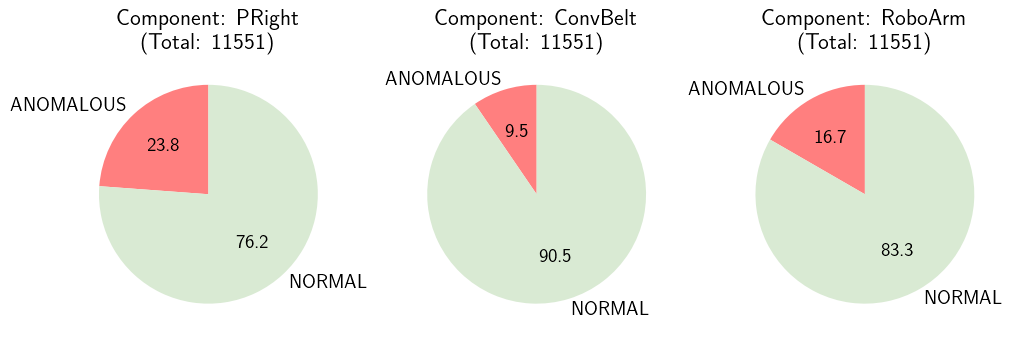

In [23]:
import matplotlib.pyplot as plt
# use latex font
plt.rcParams.update({"text.usetex": True})

fig, axes = plt.subplots(1, len(areas), figsize=(12, 6))

for area_id, area in enumerate(areas):
    print(f'{area} --> {len(df_all[(df_all.component==area) & (df_all.component_anomaly=="ANOMALOUS")])} v/s {len(df_all[(df_all.component==area) & (df_all.component_anomaly=="NORMAL")])}')
    # plot pie chart of anomaly vs normal
    df_area = df_all[df_all.component == area]
    counts = df_area['component_anomaly'].value_counts()
    counts = counts.reindex(['ANOMALOUS', 'NORMAL'], fill_value=0)
    
    axes[area_id].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=["#FF7F7F", "#d9ead3"], textprops={'fontsize': 14, 'color': 'black'})
    axes[area_id].set_title(f'Component: {area}\n(Total: {len(df_area)})', fontsize=16)
plt.show()

## DRAW PLOT FOR DATASET DISTRIBUTION

RoboArm --> 1926 v/s 9625


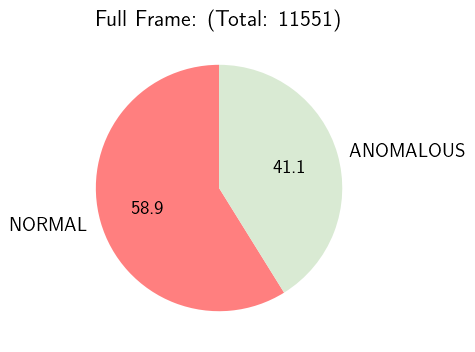

In [24]:
import matplotlib.pyplot as plt
# use latex font
plt.rcParams.update({"text.usetex": True})

fig = plt.figure( figsize=(4, 4))

print(f'{area} --> {len(df_all[(df_all.component==area) & (df_all.component_anomaly=="ANOMALOUS")])} v/s {len(df_all[(df_all.component==area) & (df_all.component_anomaly=="NORMAL")])}')
# plot pie chart of anomaly vs normal
df_area = df_all[df_all.component == area]
counts = df_area['image_anomaly'].value_counts()#.unique()
# counts = counts.reindex(['ANOMALOUS', 'NORMAL'], fill_value=0)
# plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, 
        autopct='%1.1f%%',
            startangle=90, colors=["#FF7F7F", "#d9ead3"], textprops={'fontsize': 14, 'color': 'black'})
plt.title(f'Full Frame: (Total: {len(df_area)})', fontsize=16)
plt.show()

In [47]:
paths.path_labeling = f'{paths.path_results}/labeling_result'
os.makedirs(paths.path_labeling, exist_ok=True)

csv_filename_anom_metadata = f'{paths.path_labeling}/csv_anomaly_metadata_{params.anomalous_type}.csv'

df_all.to_csv(csv_filename_anom_metadata, index=None)
print('file saved at ', csv_filename_anom_metadata)


file saved at  E:/Cloud/RashidPHD/Codes/DistriMuSe/AD_CAD_v4_real/labeling_result/csv_anomaly_metadata_unexpected_person.csv


In [48]:
idx= 4292
# idx= 8900

df_all[df_all.frame_no==idx]



,frame_no,image_anomaly,component,component_anomaly
12876,4292,ANOMALOUS,ConvBelt,NORMAL
12877,4292,ANOMALOUS,PRight,ANOMALOUS
12878,4292,ANOMALOUS,RoboArm,ANOMALOUS


In [49]:
df_all[df_all.component=='ConvBelt']

,frame_no,image_anomaly,component,component_anomaly
0,0,NORMAL,ConvBelt,NORMAL
3,1,NORMAL,ConvBelt,NORMAL
6,2,NORMAL,ConvBelt,NORMAL
9,3,NORMAL,ConvBelt,NORMAL
12,4,NORMAL,ConvBelt,NORMAL
...,...,...,...,...
34638,11546,ANOMALOUS,ConvBelt,ANOMALOUS
34641,11547,ANOMALOUS,ConvBelt,ANOMALOUS
34644,11548,ANOMALOUS,ConvBelt,ANOMALOUS
34647,11549,ANOMALOUS,ConvBelt,ANOMALOUS


In [50]:
import pandas as pd

# --- config (use your actual numbers) ---
FPS = 24.9956855638968
FRAME_COUNT = 11587
LAST = FRAME_COUNT - 1

# --- helpers ---
def secs_to_str(t: float) -> str:
    if t < 0: t = 0.0
    h = int(t // 3600); t -= h*3600
    m = int(t // 60);   t -= m*60
    if h > 0: return f"{h:02d}:{m:02d}:{t:06.3f}"
    return f"{m:02d}:{t:06.3f}"

def frame_to_str(f: int) -> str:
    return secs_to_str(f / max(FPS, 1e-9))

def clip_fix(a: int, b: int) -> tuple[int,int]:
    s, e = (a, b) if a <= b else (b, a)
    s, e = max(0, min(s, LAST)), max(0, min(e, LAST))
    return (s, e) if s <= e else None

def merge_intervals(intervals: list[tuple[int,int]]) -> list[tuple[int,int]]:
    """Merge overlapping/touching inclusive intervals."""
    if not intervals: return []
    intervals = sorted(intervals, key=lambda x: x[0])
    out = [list(intervals[0])]
    for s, e in intervals[1:]:
        ps, pe = out[-1]
        if s <= pe + 1:
            out[-1][1] = max(pe, e)
        else:
            out.append([s, e])
    return [tuple(x) for x in out]

def complement_intervals(merged_anom: list[tuple[int,int]]) -> list[tuple[int,int]]:
    """Return inclusive normal intervals within [0, LAST]."""
    normals, cur = [], 0
    for s, e in merged_anom:
        if cur <= s - 1:
            normals.append((cur, s - 1))
        cur = e + 1
    if cur <= LAST:
        normals.append((cur, LAST))
    return normals

def build_normals_df(intervals: list[tuple[int,int]]) -> pd.DataFrame:
    df = pd.DataFrame(intervals, columns=['start_frame','end_frame'])
    if df.empty:
        return pd.DataFrame(columns=['start_frame','end_frame','n_frames','start_time','end_time','duration_s','duration'])
    df['n_frames']   = df['end_frame'] - df['start_frame'] + 1
    df['start_time'] = df['start_frame'].apply(frame_to_str)
    df['end_time']   = df['end_frame'].apply(frame_to_str)
    df['duration_s'] = df['n_frames'] / FPS
    df['duration']   = df['duration_s'].apply(secs_to_str)
    return df

# --- PER-AREA NORMALS ---
normals_by_area: dict[str, pd.DataFrame] = {}

for area, g in df_metadata.groupby('safety_area', dropna=False):
    # collect anomalous intervals for this area
    anom = []
    for s, e in zip(g['activity_start'], g['activity_end']):
        fixed = clip_fix(int(s), int(e))
        if fixed: anom.append(fixed)

    merged_anom = merge_intervals(anom)
    normal_ints = complement_intervals(merged_anom)
    normals_by_area[area] = build_normals_df(normal_ints)

# Example: access DataFrames for each area
for area, df_norm in normals_by_area.items():
    print(f"\n=== NORMAL intervals for area: {area} ===")
    print(df_norm.head(10))
    total_frames = int(df_norm['n_frames'].sum()) if not df_norm.empty else 0
    total_dur_s  = float(df_norm['duration_s'].sum()) if not df_norm.empty else 0.0
    print(f"Total normal frames: {total_frames} / {FRAME_COUNT} "
          f"({100*total_frames/FRAME_COUNT:.2f}%),  ≈ {secs_to_str(total_dur_s)}")

# (Optional) save one CSV per area
# out_dir = r"D:\DS\normal_intervals_by_area"
# os.makedirs(out_dir, exist_ok=True)
# for area, df_norm in normals_by_area.items():
#     safe = str(area).replace(' ', '_')
#     df_norm.to_csv(os.path.join(out_dir, f"normals_{safe}.csv"), index=False)



=== NORMAL intervals for area: ConvBelt ===
   start_frame  end_frame  n_frames start_time   end_time  duration_s  \
0            0       1134      1135  00:00.000  00:45.368   45.407836   
1         1144       2524      1381  00:45.768  01:40.977   55.249535   
2         2660       7701      5042  01:46.418  05:08.093  201.714811   
3         7771       7778         8  05:10.894  05:11.174    0.320055   
4         7810       9721      1912  05:12.454  06:28.907   76.493201   
5         9799      10036       238  06:32.028  06:41.509    9.521643   
6        10103      10833       731  06:44.190  07:13.395   29.245047   
7        11551      11586        36  07:42.120  07:43.520    1.440249   

    duration  
0  00:45.408  
1  00:55.250  
2  03:21.715  
3  00:00.320  
4  01:16.493  
5  00:09.522  
6  00:29.245  
7  00:01.440  
Total normal frames: 10483 / 11587 (90.47%),  ≈ 06:59.392

=== NORMAL intervals for area: PRight ===
   start_frame  end_frame  n_frames start_time   end_time  du

In [58]:
anomalies_type = df_metadata.type.unique().tolist()
anomalies_type

['boxtitled', 'operator_interrupting', 'unexpected_person']

In [53]:
# safety_areas

## CREATE Folders for test set

In [59]:
safety_areas = df_metadata['safety_area'].unique().tolist()
safety_areas = areas
print('safety_areas: ', safety_areas)

# Create folders for types of anlomies
import os
import shutil
paths_train_dir = r"D:/DS/SR/cam_1/camera1_20250917_155313_crops/train"
paths_test_dir = r"D:/DS/SR/cam_1/camera1_20250917_155313_crops/test"
print('='*100)
os.makedirs(paths_train_dir, exist_ok=True)
os.makedirs(paths_test_dir, exist_ok=True)

for at in anomalies_type:
    print(at)
    print('-'*20)
    for safety_area in safety_areas:
        anomalies_type = df_metadata[df_metadata['safety_area']==safety_area].type.unique().tolist()
    
        # os.makedirs(rf"D:/DS/SR/cam_1/camera1_20250917_155313_crops/normal", exist_ok=True)
        new_folder =rf"{paths_test_dir}/{at}/{safety_area}/normal/"
        os.makedirs(new_folder, exist_ok=True)
        print('Created:', new_folder, os.path.exists(new_folder))
        #------------------------------------------------------------------------------------
        new_folder =rf"{paths_test_dir}/{at}/{safety_area}/anomalous/"
        os.makedirs(new_folder, exist_ok=True)
        print('Created:', new_folder, os.path.exists(new_folder))

    print('-'*100)


safety_areas:  ['PRight', 'ConvBelt', 'RoboArm']
boxtitled
--------------------
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/test/boxtitled/PRight/normal/ True
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/test/boxtitled/PRight/anomalous/ True
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/test/boxtitled/ConvBelt/normal/ True
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/test/boxtitled/ConvBelt/anomalous/ True
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/test/boxtitled/RoboArm/normal/ True
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/test/boxtitled/RoboArm/anomalous/ True
----------------------------------------------------------------------------------------------------
operator_interrupting
--------------------
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/test/operator_interrupting/PRight/normal/ True
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/test/operator_interrupting/PRight/anomalous/ True
Created: D:/DS/SR/cam_

## MOVE DATA?

In [86]:
# --- Build frame-wise labels ---
print('Normal frames count:', df_all[df_all['image_anomaly']=='NORMAL']['frame_no'].nunique())
print('Anomalous frames count:', df_all[df_all['image_anomaly']=='ANOMALOUS']['frame_no'].nunique())
print('-'*150)
for area in areas:
    print(f'Area: {area}')
    print('  Normal frames count:', df_all[(df_all['component_anomaly']=='NORMAL') & (df_all['component']==area)]['frame_no'].nunique())
    print('  Anomalous frames count:', df_all[(df_all['component_anomaly']=='ANOMALOUS') & (df_all['component']==area)]['frame_no'].nunique())
    print('-'*100)

df_all

Normal frames count: 6797
Anomalous frames count: 4754
------------------------------------------------------------------------------------------------------------------------------------------------------
Area: PRight
  Normal frames count: 8799
  Anomalous frames count: 2752
----------------------------------------------------------------------------------------------------
Area: ConvBelt
  Normal frames count: 10447
  Anomalous frames count: 1104
----------------------------------------------------------------------------------------------------
Area: RoboArm
  Normal frames count: 9622
  Anomalous frames count: 1929
----------------------------------------------------------------------------------------------------


,frame_no,image_anomaly,component,component_anomaly
0,0,NORMAL,ConvBelt,NORMAL
1,0,NORMAL,PRight,NORMAL
2,0,NORMAL,RoboArm,NORMAL
3,1,NORMAL,ConvBelt,NORMAL
4,1,NORMAL,PRight,NORMAL
...,...,...,...,...
34648,11549,ANOMALOUS,PRight,NORMAL
34649,11549,ANOMALOUS,RoboArm,NORMAL
34650,11550,ANOMALOUS,ConvBelt,ANOMALOUS
34651,11550,ANOMALOUS,PRight,NORMAL


In [106]:
paths_test_dir

'D:/DS/SR/cam_1/camera1_20250917_155313_crops/test'

In [ ]:
# output_dir=f"D:/DS/SR/cam_1/camera1_20250917_155313_crops/{safety_area}"
anomolous_framesmeta = []
# for event in events_raw:

for row in tqdm(df_all.itertuples()):
    frame_no = row.frame_no
    image_anomaly = row.image_anomaly
    safety_area = row.component
    component_anomaly = row.component_anomaly

    status = 'anomalous' if component_anomaly=='ANOMALOUS' else 'normal'
    # print(frame_no, image_anomaly, component, component_anomaly)
    source_file=f"D:/DS/SR/cam_1/camera1_20250917_155313_crops/{safety_area}/{safety_area}/crop_{frame_no:05}.png"
    dest_file=f"{paths_test_dir}/{event_type}/{safety_area}/{status}/crop_{frame_no:05}.png"
    print(os.path.exists(source_file), source_file)

    anomolous_framesmeta_data ={'frame':frame_no,
                                'source_file':source_file,
                                'event_type':event_type,

                                   }
    anomolous_framesmeta.append(anomolous_framesmeta_data)
        # MOVE FILE? 
    if os.path.exists(source_file):
        shutil.copy(source_file,dest_file)
            
            # shutil.move(source_file,dest_file)
            # print(os.path.exists(dest_file), dest_file)
            
    else:
        pass
            # print('SOURCE FILE NOT FOUND')

        
        # break


    # break

0it [00:00, ?it/s]

0 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/camera1_20250917_155313_crops/ConvBelt/ConvBelt/crop_00000.png
0 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/camera1_20250917_155313_crops/PRight/PRight/crop_00000.png
0 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/camera1_20250917_155313_crops/RoboArm/RoboArm/crop_00000.png
1 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/camera1_20250917_155313_crops/ConvBelt/ConvBelt/crop_00001.png
1 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/camera1_20250917_155313_crops/PRight/PRight/crop_00001.png
1 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/camera1_20250917_155313_crops/RoboArm/RoboArm/crop_00001.png
2 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/camera1_20250917_155313_crops/ConvBelt/ConvBelt/crop_00002.png
2 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/camera1_20250917_155313_crops/PRight/PRight/crop_00002.png
2 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/camera1_20250917_155313_crops/RoboArm/RoboArm/crop_00002.png
3 NORMAL ConvBelt NORMAL
True D:/DS/SR/cam_1/c

In [110]:
pd.DataFrame(anomolous_framesmeta)

,frame,source_file,event_type
0,0,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...,unexpected_person
1,0,D:/DS/SR/cam_1/camera1_20250917_155313_crops/P...,unexpected_person
2,0,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...,unexpected_person
3,1,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...,unexpected_person
4,1,D:/DS/SR/cam_1/camera1_20250917_155313_crops/P...,unexpected_person
...,...,...,...
34648,11549,D:/DS/SR/cam_1/camera1_20250917_155313_crops/P...,unexpected_person
34649,11549,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...,unexpected_person
34650,11550,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...,unexpected_person
34651,11550,D:/DS/SR/cam_1/camera1_20250917_155313_crops/P...,unexpected_person


In [82]:
# events_with_normals

In [ ]:
# # output_dir=f"D:/DS/SR/cam_1/camera1_20250917_155313_crops/{safety_area}"
# anomolous_framesmeta = []
# # for event in events_raw:
# for event in tqdm(events_with_normals, desc='Event Types'):
#     # print(event)
#     event_type,status, safety_area, start_frame, end_frame = event
#     anomalous_frames = list(range(start_frame, end_frame+1))
#     print(f'{len(anomalous_frames)} are {status} for {event_type} in {safety_area}')
#     print('-'*100)
#     for frame in tqdm(anomalous_frames, desc = f'Processing {event_type} in {safety_area}'):
#         source_file=f"D:/DS/SR/cam_1/camera1_20250917_155313_crops/{safety_area}/crop_{frame:05}.png"
#         dest_file=f"{paths_test_dir}/{event_type}/{safety_area}/{status}/crop_{frame:05}.png"
#         anomolous_framesmeta_data ={'frame':frame,
#                                     'source_file':source_file,
#                                     'event_type':event_type,
#                                     # 'type':event_type,
#                                 #    'safety_area':safety_area,
#                                 #    'activity_start':start_frame,
#                                 #    'activity_end':end_frame,
#                                    }
#         anomolous_framesmeta.append(anomolous_framesmeta_data)
#         # MOVE FILE? 
#         if os.path.exists(source_file):
#             shutil.copy(source_file,dest_file)
            
#             # shutil.move(source_file,dest_file)
#             # print(os.path.exists(dest_file), dest_file)
            
#         else:
#             pass
#             # print('SOURCE FILE NOT FOUND')

        
#         # break


#     # break

Event Types:   0%|          | 0/70 [00:00<?, ?it/s]

1135 are normal for boxtitled in ConvBelt
----------------------------------------------------------------------------------------------------


Processing boxtitled in ConvBelt:   0%|          | 0/1135 [00:00<?, ?it/s]

9 are anomalous for boxtitled in ConvBelt
----------------------------------------------------------------------------------------------------


Processing boxtitled in ConvBelt:   0%|          | 0/9 [00:00<?, ?it/s]

...

Processing unexpected_person in RoboArm:   0%|          | 0/269 [00:00<?, ?it/s]

39 are anomalous for unexpected_person in RoboArm
----------------------------------------------------------------------------------------------------


Processing unexpected_person in RoboArm:   0%|          | 0/39 [00:00<?, ?it/s]

2623 are normal for unexpected_person in RoboArm
----------------------------------------------------------------------------------------------------


Processing unexpected_person in RoboArm:   0%|          | 0/2623 [00:00<?, ?it/s]

In [71]:
pd.DataFrame(anomolous_framesmeta)

,frame,source_file,event_type
0,0,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...,boxtitled
1,1,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...,boxtitled
2,2,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...,boxtitled
3,3,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...,boxtitled
4,4,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...,boxtitled
...,...,...,...
103954,11546,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...,unexpected_person
103955,11547,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...,unexpected_person
103956,11548,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...,unexpected_person
103957,11549,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...,unexpected_person


# MOVE REST OF THE DATA TO TRAIN DATA

In [ ]:
safety_areas = df_metadata['safety_area'].unique().tolist()
print('safety_areas: ', safety_areas)

# Create folders for types of anlomies
import os
import shutil
paths_train_dir = r"D:/DS/SR/cam_1/camera1_20250917_155313_crops/train"

print('='*100)
os.makedirs(paths_train_dir, exist_ok=True)
for safety_area in safety_areas:
    # anomalies_type = df_metadata[df_metadata['safety_area']==safety_area].type.unique().tolist()

    # os.makedirs(rf"D:/DS/SR/cam_1/camera1_20250917_155313_crops/normal", exist_ok=True)
    new_folder =rf"{paths_train_dir}/{safety_area}/normal/"

    os.makedirs(new_folder, exist_ok=True)
    print('Created:', new_folder, os.path.exists(new_folder))
    print('-'*100)


safety_areas:  ['RoboArm', 'ConvBelt', 'PRight']
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/train/RoboArm/normal/ True
----------------------------------------------------------------------------------------------------
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/train/ConvBelt/normal/ True
----------------------------------------------------------------------------------------------------
Created: D:/DS/SR/cam_1/camera1_20250917_155313_crops/train/PRight/normal/ True
----------------------------------------------------------------------------------------------------


In [99]:
import pandas as pd
from pathlib import Path
import shutil

def merge_intervals(intervals):
    """intervals: list of (start, end), inclusive."""
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1] + 1:   # overlap or touch
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(s, e) for s, e in merged]

def complement_intervals(merged, start=0, end=None):
    """
    merged: merged anomalous intervals (inclusive).
    start/end: inclusive bounds for the full frame range.
    If end is None, uses the max end from merged.
    """
    if end is None:
        end = max(e for _, e in merged) if merged else start
    normals = []
    prev_end = start - 1
    for s, e in merged:
        if s - 1 >= prev_end + 1:
            normals.append((prev_end + 1, s - 1))
        prev_end = max(prev_end, e)
    if prev_end < end:
        normals.append((prev_end + 1, end))
    return normals

def get_global_normal_ranges(df, start_frame=0, end_frame=None):
    # 1) Collect all anomaly intervals (whatever the type/component)
    intervals = list(zip(df['activity_start'].astype(int),
                         df['activity_end'].astype(int)))
    # 2) Merge overlaps
    merged_anomalous = merge_intervals(intervals)
    # 3) Complement -> globally normal
    if end_frame is None:
        end_frame = max(df['activity_end'])
    return complement_intervals(merged_anomalous, start=start_frame, end=end_frame)

# ---------- Example usage ----------
# df = pd.DataFrame(your_table_as_above)
# global_normal = get_global_normal_ranges(df, start_frame=0)  # end inferred from table
# print(global_normal)

# ---------- (Optional) Move/copy only globally-normal frames ----------
def move_globally_normal_frames(global_normal_ranges,
                                src_dir,
                                dst_dir,
                                pattern="{:06d}.jpg",
                                copy_instead=False):
    """
    pattern controls filename format, e.g. 000123.jpg -> pattern="{:06d}.jpg".
    Set copy_instead=True to copy instead of move.
    """
    src = Path(src_dir)
    dst = Path(dst_dir)
    dst.mkdir(parents=True, exist_ok=True)

    mover = shutil.copy2 if copy_instead else shutil.move

    for s, e in global_normal_ranges:
        for idx in range(s, e + 1):  # inclusive
            fname = pattern.format(idx)
            fpath = src / fname
            if fpath.exists():
                mover(str(fpath), str(dst / fname))
    return dst


In [ ]:
global_normal = get_global_normal_ranges(df, start_frame=0)
move_globally_normal_frames(global_normal,
                            src_dir="path/to/frames",
                            dst_dir="path/to/frames_normal",
                            pattern="{:06d}.jpg",   # adjust if your naming differs
                            copy_instead=True)     # True to copy instead of move


In [ ]:

df_metadata_filtered = df_metadata[df_metadata.type==params.anomalous_type]
df_metadata_filtered


# Inputs
start_frame = 0
end_frame = 11550

# Make sure df_metadata_filtered has at least: [type, safety_area, activity_start, activity_end]
# areas = sorted(df_metadata_filtered['safety_area'].unique())
areas = ['PRight','ConvBelt','RoboArm']

# 1) Collect anomalous frames per area
anom_by_area = {area: set() for area in areas}
for _, row in df_metadata_filtered.iterrows():
    anom_by_area[row.safety_area].update(range(row.activity_start, row.activity_end + 1))

# 2) Build rows: one per (frame, area)
data_csv = []
for f in range(start_frame, end_frame + 1):
    any_area_anom = any(f in anom_by_area[area] for area in areas)
    img_label = 'ANOMALOUS' if any_area_anom else 'NORMAL'
    for area in areas:
        comp_label = 'ANOMALOUS' if f in anom_by_area[area] else 'NORMAL'
        data_csv.append({
            'frame_no': f,
            'image_anomaly': img_label,
            'component': area,
            'component_anomaly': comp_label,
        })

df_all = pd.DataFrame(data_csv)
# Optional: keep sorted and reset index
df_all.sort_values(['frame_no', 'component'], inplace=True)
df_all.reset_index(drop=True, inplace=True)
df_all



In [91]:
# output_dir=f"D:/DS/SR/cam_1/camera1_20250917_155313_crops/{safety_area}"
normal_framesmeta = []
# for event in events_raw:
for event in tqdm(events_with_normals, desc='Event Types'):
    
    event_type,status, safety_area, start_frame, end_frame = event
    if status =='normal':
        print(event)
        
    # print(event_type,status, safety_area, start_frame, end_frame)
    else:
        continue
    # break
    normal_frames = list(range(start_frame, end_frame+1))
    

    # anomalous_frames = list(range(start_frame, end_frame+1))

    print(f'normal' if status=='normal' else 'anomalous', len(normal_frames), safety_area )
    for frame in tqdm(normal_frames, desc = f'Processing {event_type} in {safety_area}'):
        source_file=f"D:/DS/SR/cam_1/camera1_20250917_155313_crops/{safety_area}/crop_{frame:05}.png"
        dest_file=f"{paths_train_dir}/{event_type}/{safety_area}/{status}/crop_{frame:05}.png"
        normal_framesmeta_data ={'frame':frame,
                                 'source_file':source_file,
                                    # 'type':event_type,
                                #    'safety_area':safety_area,
                                #    'activity_start':start_frame,
                                #    'activity_end':end_frame,
                                   }
        normal_framesmeta.append(normal_framesmeta_data)
        # MOVE FILE? 
        # if os.path.exists(source_file):
            # shutil.copy(source_file,dest_file)
            
            # shutil.move(source_file,dest_file)
            # print(os.path.exists(dest_file), dest_file)
            
        # else:
        #     pass
        #     # print('SOURCE FILE NOT FOUND')

        
        # break


    # break

Event Types:   0%|          | 0/70 [00:00<?, ?it/s]

('boxtitled', 'normal', 'ConvBelt', 0, 1134)
normal 1135 ConvBelt


Processing boxtitled in ConvBelt:   0%|          | 0/1135 [00:00<?, ?it/s]

('boxtitled', 'normal', 'ConvBelt', 1144, 11550)
normal 10407 ConvBelt


Processing boxtitled in ConvBelt:   0%|          | 0/10407 [00:00<?, ?it/s]

...

Processing unexpected_person in RoboArm:   0%|          | 0/537 [00:00<?, ?it/s]

('unexpected_person', 'normal', 'RoboArm', 8620, 8888)
normal 269 RoboArm


Processing unexpected_person in RoboArm:   0%|          | 0/269 [00:00<?, ?it/s]

('unexpected_person', 'normal', 'RoboArm', 8928, 11550)
normal 2623 RoboArm


Processing unexpected_person in RoboArm:   0%|          | 0/2623 [00:00<?, ?it/s]

In [89]:
normal_framesmeta_df = pd.DataFrame(normal_framesmeta)
normal_framesmeta_df

,frame,source_file
0,0,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...
1,1,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...
2,2,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...
3,3,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...
4,4,D:/DS/SR/cam_1/camera1_20250917_155313_crops/C...
...,...,...
98169,11546,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...
98170,11547,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...
98171,11548,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...
98172,11549,D:/DS/SR/cam_1/camera1_20250917_155313_crops/R...


In [73]:
# # output_dir=f"D:/DS/SR/cam_1/camera1_20250917_155313_crops/{safety_area}"
# # anomolous_framesmeta = []
# for safety_area in safety_areas:
#     source_file=f"D:/DS/SR/cam_1/camera1_20250917_155313_crops/{safety_area}"
#     dest_file=f"{paths_train_dir}/{safety_area}"
#     if os.path.exists(source_file):
#         shutil.move(source_file,dest_file)
#         print('Moved:', source_file, '→', dest_file)
#     else:
#         print('SOURCE FILE NOT FOUND', source_file)

In [20]:
def normalize_area(area):
    # ensure tuple
    if isinstance(area, (list, tuple)):
        return tuple(area)
    return (area,)

def clip_interval(a: int, b: int) -> tuple[int,int]:
    return max(0, min(a, LAST_FRAME)), max(0, min(b, LAST_FRAME))

def merge_ranges(ranges):
    """
    ranges: list of (start, end) inclusive; returns merged list.
    Merges overlapping or touching (end+1 == next start) intervals.
    """
    if not ranges:
        return []
    ranges = sorted(ranges, key=lambda x: x[0])
    out = [list(ranges[0])]
    for s, e in ranges[1:]:
        ps, pe = out[-1]
        if s <= pe + 1:
            out[-1][1] = max(pe, e)
        else:
            out.append([s, e])
    return [tuple(x) for x in out]

def frame_to_str(f: int) -> str:
    return secs_to_str(f / max(FPS, 1e-9))

def secs_to_str(t: float) -> str:
    if t < 0: t = 0.0
    h = int(t // 3600); t -= h*3600
    m = int(t // 60);   t -= m*60
    if h > 0:
        return f"{h:02d}:{m:02d}:{t:06.3f}"
    return f"{m:02d}:{t:06.3f}"

In [21]:
FPS = 24.9956855638968
FRAME_COUNT = 11587
LAST_FRAME = FRAME_COUNT - 1

# ------------------ NORMALIZE, CLIP, AND MERGE ------------------
# 1) Normalize and clip
norm = []
for label, area, a, b in events_raw:
    area = normalize_area(area)
    s, e = (a, b) if a <= b else (b, a)          # auto-swap if reversed
    s, e = clip_interval(s, e)
    if s > e: 
        continue
    norm.append((label, area, s, e))

# 2) Group by (label, area) and merge overlapping/adjacent
from collections import defaultdict
groups = defaultdict(list)
for label, area, s, e in norm:
    groups[(label, area)].append((s, e))

merged = []
for (label, area), spans in groups.items():
    for s, e in merge_ranges(spans):
        merged.append((label, area, s, e))

# 3) Sort by start frame for readability
merged.sort(key=lambda x: x[2])

# 4) Print a refined summary
total_anom_frames = 0
print(f"{'Label':24} {'Area':18} {'Frames (start-end)':22} {'#Frames':>8} {'Time (start - end)':24} {'Duration'}")
print("-"*100)
for label, area, s, e in merged:
    n = e - s + 1
    total_anom_frames += n
    print(f"{label:24} {str(area):18} {f'{s}-{e}':22} {n:8d} {f'{frame_to_str(s)} - {frame_to_str(e)}':24} {secs_to_str(n/FPS)}")

print("-"*100)
print(f"Total anomalous frames: {total_anom_frames} / {FRAME_COUNT} "
      f"({100.0*total_anom_frames/FRAME_COUNT:.2f}%),  "
      f"≈ {secs_to_str(total_anom_frames/FPS)} of video time.")

Label                    Area               Frames (start-end)      #Frames Time (start - end)       Duration
----------------------------------------------------------------------------------------------------
boxtitled                ('RoboArm', 'ConvBelt') 1120-1143                    24 00:44.808 - 00:45.728    00:00.960
operator_interrupting    ('ConvBelt',)      2529-2665                   137 01:41.177 - 01:46.618    00:05.481
operator_interrupting    ('RoboArm',)       2545-2633                    89 01:41.818 - 01:45.338    00:03.561
unexpected_person        ('RoboArm',)       4252-4300                    49 02:50.109 - 02:52.030    00:01.960
unexpected_person        ('PRight',)        4280-4560                   281 02:51.230 - 03:02.431    00:11.242
unexpected_person        ('PRight',)        4930-5787                   858 03:17.234 - 03:51.520    00:34.326
unexpected_person        ('RoboArm',)       5000-5170                   171 03:20.035 - 03:26.836    00:06.841
unexpec

<!-- ## copy_folder_structure -->